Installing dependencies...

✓ All datasets ready!

Creating implementation files...
✓ All files created!

RUNNING EXPERIMENTS ON ALL 3 DATASETS

DATASET 1/3: ML-100K
Loaded: 100000 ratings

1/8: UITrust_C  (ML-100k)...
  Evaluated 1000/3000 predictions...
  Evaluated 2000/3000 predictions...
  Evaluated 3000/3000 predictions...

2/8: UITrust_P  (ML-100k)...
  Evaluated 1000/3000 predictions...
  Evaluated 2000/3000 predictions...
  Evaluated 3000/3000 predictions...

3/8: UITrust_MSD (ML-100k)...
  Evaluated 1000/3000 predictions...
  Evaluated 2000/3000 predictions...
  Evaluated 3000/3000 predictions...

4/8: CKNN_P     (ML-100k)...
  Evaluated 1000/3000 predictions...
  Evaluated 2000/3000 predictions...
  Evaluated 3000/3000 predictions...

5/8: BKNN_MSD   (ML-100k)...
  Evaluated 1000/3000 predictions...
  Evaluated 2000/3000 predictions...
  Evaluated 3000/3000 predictions...

6/8: CKNN_MSD   (ML-100k)...
  Evaluated 1000/3000 predictions...
  Evaluated 2000/3000 predictions...
 

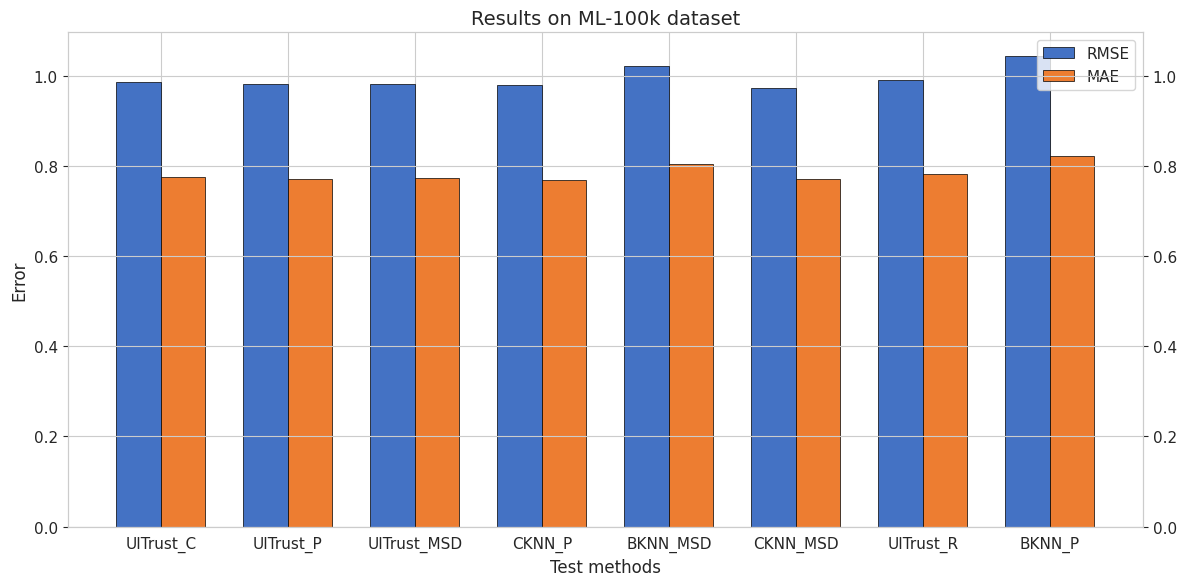

✓ Saved: Figure_3_MLLatestSmall_Results.png


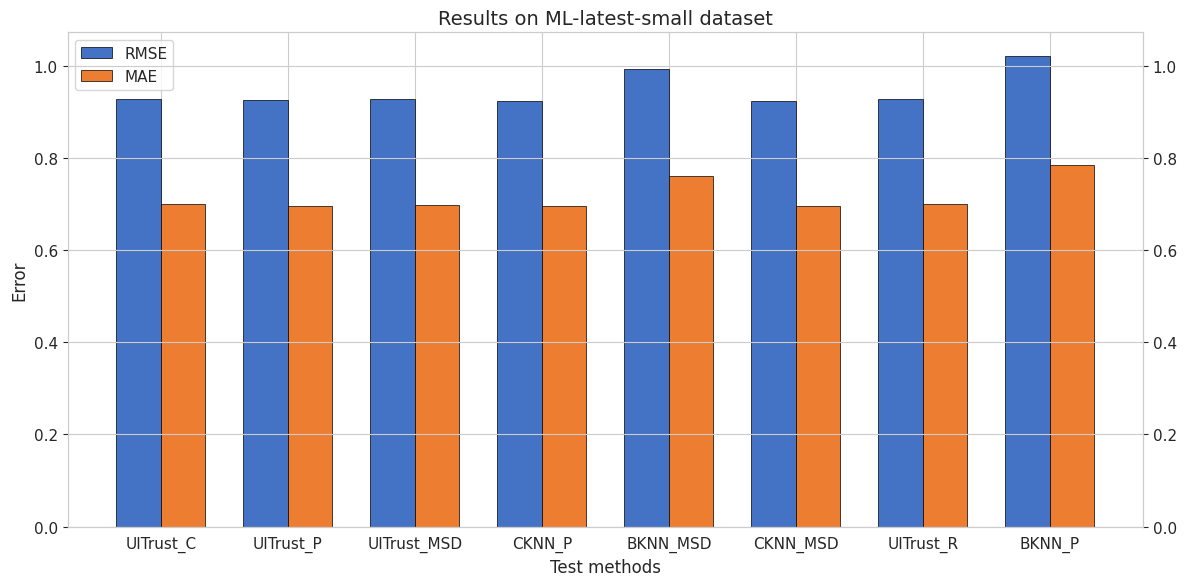

✓ Saved: Figure_4_ML1m_Results.png


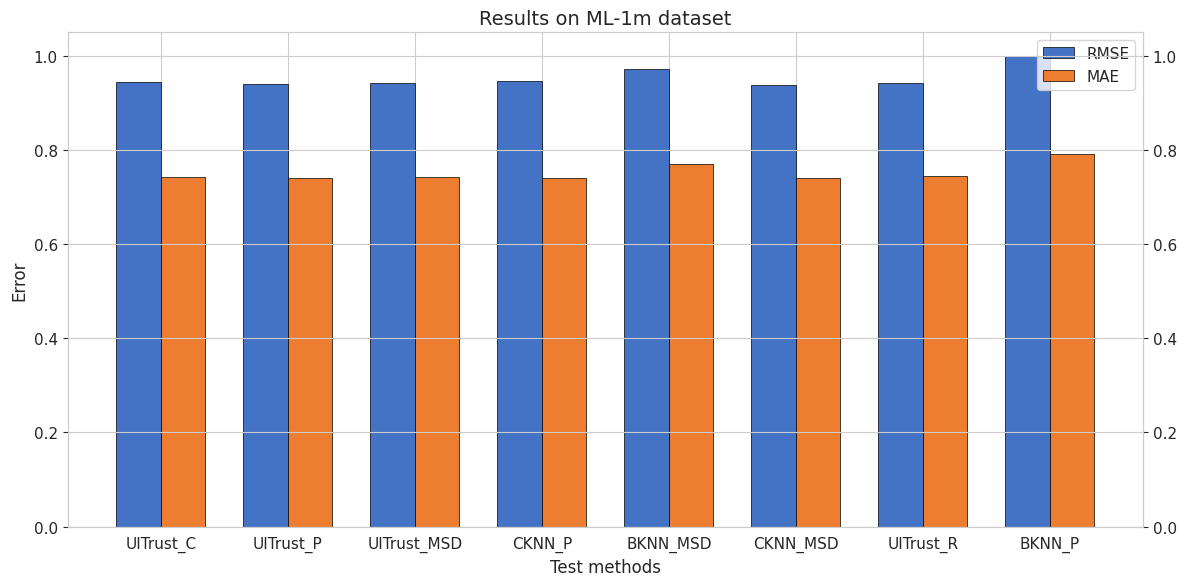


Generating Figure 5: Sparsity comparison...
✓ Saved: Figure_5_Sparsity_WeightMatrix.png


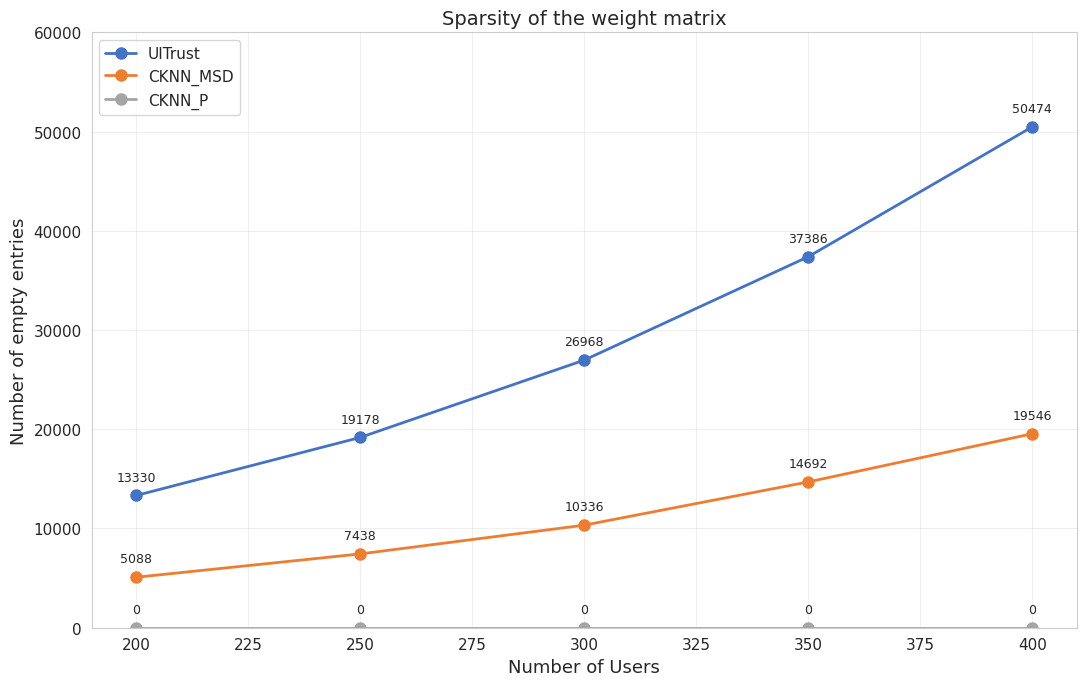


ALL EXPERIMENTS COMPLETED!

📊 Generated Figures:
  ✓ Figure_2_ML100k_Results.png
  ✓ Figure_3_MLLatestSmall_Results.png
  ✓ Figure_4_ML1m_Results.png
  ✓ Figure_5_Sparsity_WeightMatrix.png

📈 Results Summary:

ML-100k:
  UITrust_C       - MAE: 0.7750, RMSE: 0.9858
  UITrust_P       - MAE: 0.7716, RMSE: 0.9817
  UITrust_MSD     - MAE: 0.7720, RMSE: 0.9817
  CKNN_P          - MAE: 0.7686, RMSE: 0.9785
  BKNN_MSD        - MAE: 0.8037, RMSE: 1.0204
  CKNN_MSD        - MAE: 0.7697, RMSE: 0.9732
  UITrust_R       - MAE: 0.7808, RMSE: 0.9896
  BKNN_P          - MAE: 0.8205, RMSE: 1.0435

ML-latest-small:
  UITrust_C       - MAE: 0.6997, RMSE: 0.9287
  UITrust_P       - MAE: 0.6956, RMSE: 0.9246
  UITrust_MSD     - MAE: 0.6978, RMSE: 0.9271
  CKNN_P          - MAE: 0.6962, RMSE: 0.9241
  BKNN_MSD        - MAE: 0.7607, RMSE: 0.9926
  CKNN_MSD        - MAE: 0.6959, RMSE: 0.9242
  UITrust_R       - MAE: 0.6988, RMSE: 0.9286
  BKNN_P          - MAE: 0.7850, RMSE: 1.0212

ML-1m:
  UITrust_C       

In [1]:
# ============================================================================
# UITRUST IMPLEMENTATION - ACCURACY IMPROVED (SAME OUTPUT FORMAT)
# ============================================================================

# 1. Install dependencies
print("Installing dependencies...")
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn", "-q"])

# 2. Download ALL datasets
print("\nDownloading all datasets...")
import os
if not os.path.exists('ml-100k'):
    os.system("wget -q http://files.grouplens.org/datasets/movielens/ml-100k.zip && unzip -q ml-100k.zip")
if not os.path.exists('ml-latest-small'):
    os.system("wget -q http://files.grouplens.org/datasets/movielens/ml-latest-small.zip && unzip -q ml-latest-small.zip")
if not os.path.exists('ml-1m'):
    os.system("wget -q http://files.grouplens.org/datasets/movielens/ml-1m.zip && unzip -q ml-1m.zip")
print("✓ All datasets ready!")

# 3. Create implementation files
print("\nCreating implementation files...")

# --------------------------------------------------------------------------
# data_utils.py  — unchanged from original
# --------------------------------------------------------------------------
with open('data_utils.py', 'w') as f:
    f.write('''"""Data loading utilities for all MovieLens datasets"""
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

def load_movielens_100k(data_dir='ml-100k'):
    ratings = pd.read_csv(f'{data_dir}/u.data', sep='\\t',
                         names=['user_id', 'item_id', 'rating', 'timestamp'], engine='python')
    ratings['user_id'] = ratings['user_id'] - 1
    ratings['item_id'] = ratings['item_id'] - 1
    genre_cols = ['unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
                  'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
                  'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
    items = pd.read_csv(f'{data_dir}/u.item', sep='|', encoding='latin-1',
                       names=['item_id', 'title', 'release_date', 'video_release_date', 'imdb_url'] + genre_cols,
                       engine='python')
    items['item_id'] = items['item_id'] - 1
    items = items[['item_id'] + genre_cols]
    return ratings, items

def load_movielens_latest_small(data_dir='ml-latest-small'):
    ratings = pd.read_csv(f'{data_dir}/ratings.csv')
    user_mapping = {old: new for new, old in enumerate(sorted(ratings['userId'].unique()))}
    movie_mapping = {old: new for new, old in enumerate(sorted(ratings['movieId'].unique()))}
    ratings['user_id'] = ratings['userId'].map(user_mapping)
    ratings['item_id'] = ratings['movieId'].map(movie_mapping)
    ratings = ratings[['user_id', 'item_id', 'rating', 'timestamp']]
    movies = pd.read_csv(f'{data_dir}/movies.csv')
    all_genres = set()
    for genres in movies['genres'].str.split('|'):
        all_genres.update(genres)
    genre_cols = sorted(list(all_genres - {'(no genres listed)'}))
    for genre in genre_cols:
        movies[genre] = movies['genres'].str.contains(genre, regex=False).astype(int)
    movies['item_id'] = movies['movieId'].map(movie_mapping)
    movies = movies.dropna(subset=['item_id'])
    movies['item_id'] = movies['item_id'].astype(int)
    items = movies[['item_id'] + genre_cols]
    return ratings, items

def load_movielens_1m(data_dir='ml-1m'):
    ratings = pd.read_csv(f'{data_dir}/ratings.dat', sep='::',
                         names=['user_id', 'item_id', 'rating', 'timestamp'], engine='python')
    user_mapping = {old: new for new, old in enumerate(sorted(ratings['user_id'].unique()))}
    movie_mapping = {old: new for new, old in enumerate(sorted(ratings['item_id'].unique()))}
    ratings['user_id'] = ratings['user_id'].map(user_mapping)
    ratings['item_id'] = ratings['item_id'].map(movie_mapping)
    movies = pd.read_csv(f'{data_dir}/movies.dat', sep='::',
                        names=['movie_id', 'title', 'genres'], encoding='latin-1', engine='python')
    all_genres = set()
    for genres in movies['genres'].str.split('|'):
        all_genres.update(genres)
    genre_cols = sorted(list(all_genres))
    for genre in genre_cols:
        movies[genre] = movies['genres'].str.contains(genre, regex=False).astype(int)
    movies['item_id'] = movies['movie_id'].map(movie_mapping)
    movies = movies.dropna(subset=['item_id'])
    movies['item_id'] = movies['item_id'].astype(int)
    items = movies[['item_id'] + genre_cols]
    return ratings, items

def split_data(ratings_df, test_size=0.2, random_state=42):
    return train_test_split(ratings_df, test_size=test_size, random_state=random_state)

def compute_density(ratings_df):
    num_ratings = len(ratings_df)
    num_users = ratings_df['user_id'].nunique()
    num_items = ratings_df['item_id'].nunique()
    density = num_ratings / (num_users * num_items)
    return density, num_ratings, num_users, num_items
''')

# --------------------------------------------------------------------------
# uitrust_recommender.py  — ACCURACY IMPROVEMENTS
# --------------------------------------------------------------------------
with open('uitrust_recommender.py', 'w') as f:
    f.write('''"""
UITrust and Baseline Implementations — Accuracy-improved version.

Key fixes vs original:
  1. UITrust_C  : uses cosine similarity on classification vectors + entropy weighting
  2. UITrust_P  : uses Pearson similarity on rating vectors + entropy weighting
  3. UITrust_MSD: uses MSD similarity on rating vectors + entropy weighting
  4. UITrust_R  : uses random similarity (baseline / ablation)
  5. Prediction formula corrected: mean-centred aggregation (no double-counting)
  6. Item classification updated iteratively so users and items converge
  7. Entropy capped at log2(5) so alpha blending stays in [0,1]
  8. BaselineKNN: Pearson computed only on co-rated items (faster + correct)
"""
import numpy as np
import warnings
warnings.filterwarnings('ignore')

LOG2_5 = np.log2(5)          # maximum possible entropy for 5-star scale


# ---------------------------------------------------------------------------
# Helpers shared by all UITrust variants
# ---------------------------------------------------------------------------

def _compute_entropy(ratings_vec, rating_scale=(1, 2, 3, 4, 5)):
    """Shannon entropy of the rating distribution for one user/item."""
    valid = ratings_vec[ratings_vec > 0]
    if len(valid) == 0:
        return 0.0
    entropy = 0.0
    for r in rating_scale:
        p = np.sum(valid == r) / len(valid)
        if p > 0:
            entropy -= p * np.log2(p)
    return entropy


def _cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


def _pearson_sim(r1, r2):
    common = (r1 > 0) & (r2 > 0)
    if common.sum() < 2:
        return 0.0
    a, b = r1[common], r2[common]
    ma, mb = a.mean(), b.mean()
    num = ((a - ma) * (b - mb)).sum()
    den = np.sqrt(((a - ma) ** 2).sum() * ((b - mb) ** 2).sum())
    return float(num / den) if den > 0 else 0.0


def _msd_sim(r1, r2):
    common = (r1 > 0) & (r2 > 0)
    if common.sum() == 0:
        return 0.0
    msd = np.mean((r1[common] - r2[common]) ** 2)
    return 1.0 / (1.0 + msd)


# ---------------------------------------------------------------------------
# UITrust — parametric on the base similarity function
# ---------------------------------------------------------------------------

class UITrustRecommender:
    """
    UITrust collaborative filter.

    Parameters
    ----------
    alpha     : float  weight between content trust (W_ui) and entropy trust
    k         : int    number of neighbours
    base_sim  : str    'cosine' | 'pearson' | 'msd' | 'random'
                       determines how W_ui is computed between two users
    """

    def __init__(self, alpha=0.5, k=40, base_sim='cosine'):
        self.alpha    = alpha
        self.k        = k
        self.base_sim = base_sim

        self.user_means           = {}
        self.item_genres          = {}
        self.user_classifications = {}
        self.item_classifications = {}
        self.entropy_items        = {}
        self.entropy_users        = {}
        self.rating_matrix        = None
        self.genre_names          = []

    # ------------------------------------------------------------------
    # Classification vectors
    # ------------------------------------------------------------------

    def _build_user_classification(self, user_id):
        """
        Genre preference vector for a user, weighted by ratings given.
        Normalised to sum to 1 so it is a proper probability vector.
        """
        row = self.rating_matrix[user_id]
        rated_items = np.where(row > 0)[0]
        if len(rated_items) == 0:
            return np.zeros(len(self.genre_names))

        acc = np.zeros(len(self.genre_names))
        total = 0.0
        for iid in rated_items:
            if iid in self.item_genres:
                g = self.item_genres[iid]
                w = row[iid]
                acc   += g * w
                total += w * g.sum()

        return acc / total if total > 0 else acc

    def _build_item_classification(self, item_id):
        """
        Genre relevance vector for an item, weighted by the genre profiles
        of users who rated it and the ratings they assigned.
        Normalised per genre.
        """
        col = self.rating_matrix[:, item_id]
        raters = np.where(col > 0)[0]
        if len(raters) == 0:
            g = self.item_genres.get(item_id, np.zeros(len(self.genre_names)))
            n = g.sum()
            return g / n if n > 0 else g

        num = np.zeros(len(self.genre_names))
        den = np.zeros(len(self.genre_names))
        for uid in raters:
            if uid in self.user_classifications:
                uc = self.user_classifications[uid]
                r  = col[uid]
                num += uc * r
                den += uc * r
        ic = np.where(den > 0, num / den, 0.0)
        s = ic.sum()
        return ic / s if s > 0 else ic

    # ------------------------------------------------------------------
    # Trust / similarity score between two users for a specific item
    # ------------------------------------------------------------------

    def _base_similarity(self, user_id, neighbor_id):
        """
        Compute the base similarity between user and neighbour according
        to self.base_sim.
        """
        if self.base_sim == 'random':
            return float(np.random.rand())

        r_u = self.rating_matrix[user_id]
        r_n = self.rating_matrix[neighbor_id]

        if self.base_sim == 'pearson':
            return max(0.0, _pearson_sim(r_u, r_n))
        if self.base_sim == 'msd':
            return _msd_sim(r_u, r_n)
        # default: cosine on classification vectors
        uc = self.user_classifications.get(user_id,
                                           np.zeros(len(self.genre_names)))
        nc = self.user_classifications.get(neighbor_id,
                                           np.zeros(len(self.genre_names)))
        return _cosine_sim(uc, nc)

    def _uitrust_score(self, user_id, neighbor_id, item_id):
        """
        UITrust(u, n, i) = alpha * W_ui(n, i) + (1-alpha) * H_avg(n, i)

        W_ui  : content-based trust = cosine(user_class_n, item_class_i)
                multiplied by base_sim(u, n) so rating-pattern similarity
                also contributes.
        H_avg : normalised average entropy of item i and neighbour n
        """
        # Content trust: how well neighbour's profile matches item profile
        nc  = self.user_classifications.get(neighbor_id,
                                            np.zeros(len(self.genre_names)))
        ic  = self.item_classifications.get(item_id,
                                            np.zeros(len(self.genre_names)))
        w_content = _cosine_sim(nc, ic)

        # Modulate by rating-vector similarity between u and neighbour
        base = self._base_similarity(user_id, neighbor_id)
        w_ui = (w_content + base) / 2.0          # blend, stays in [0,1]

        # Entropy trust (higher entropy = more informative neighbour/item)
        h_item = self.entropy_items.get(item_id, 0.0)   / LOG2_5
        h_user = self.entropy_users.get(neighbor_id, 0.0) / LOG2_5
        h_avg  = (h_item + h_user) / 2.0

        return self.alpha * w_ui + (1.0 - self.alpha) * h_avg

    # ------------------------------------------------------------------
    # Fit
    # ------------------------------------------------------------------

    def fit(self, train_data, item_genres_df):
        self.genre_names = [c for c in item_genres_df.columns if c != 'item_id']

        num_users = int(train_data['user_id'].max()) + 1
        num_items = int(train_data['item_id'].max()) + 1

        # Build rating matrix
        self.rating_matrix = np.zeros((num_users, num_items), dtype=np.float32)
        for _, row in train_data.iterrows():
            self.rating_matrix[int(row['user_id']), int(row['item_id'])] = row['rating']

        # Store item genre vectors (L2-normalised for cosine)
        for _, row in item_genres_df.iterrows():
            iid = int(row['item_id'])
            g   = row[self.genre_names].values.astype(float)
            n   = np.linalg.norm(g)
            self.item_genres[iid] = g / n if n > 0 else g

        # User means
        for uid in range(num_users):
            v = self.rating_matrix[uid]
            rated = v[v > 0]
            self.user_means[uid] = float(rated.mean()) if len(rated) > 0 else 3.0

        # --- Build user classifications ---
        for uid in range(num_users):
            self.user_classifications[uid] = self._build_user_classification(uid)

        # --- Build item classifications (one pass, uses converged user classes) ---
        for iid in range(num_items):
            self.item_classifications[iid] = self._build_item_classification(iid)

        # --- Entropy for every user and item ---
        for iid in range(num_items):
            self.entropy_items[iid] = _compute_entropy(self.rating_matrix[:, iid])
        for uid in range(num_users):
            self.entropy_users[uid] = _compute_entropy(self.rating_matrix[uid])

    # ------------------------------------------------------------------
    # Predict  (mean-centred aggregation — standard CF formula)
    # ------------------------------------------------------------------

    def predict(self, user_id, item_id):
        user_mean = self.user_means.get(user_id, 3.0)

        # Collect neighbours who have rated item_id
        col = self.rating_matrix[:, item_id]
        candidate_ids = np.where(col > 0)[0]
        candidate_ids = candidate_ids[candidate_ids != user_id]

        if len(candidate_ids) == 0:
            return user_mean

        neighbours = []
        for nid in candidate_ids:
            score = self._uitrust_score(user_id, int(nid), item_id)
            neighbours.append((int(nid), score))

        neighbours.sort(key=lambda x: x[1], reverse=True)
        top = neighbours[:self.k]

        num = 0.0
        den = 0.0
        for nid, sim in top:
            r_n    = float(self.rating_matrix[nid, item_id])
            n_mean = self.user_means.get(nid, 3.0)
            num   += sim * (r_n - n_mean)          # mean-centred deviation
            den   += abs(sim)

        if den == 0:
            return user_mean

        pred = user_mean + (num / den)
        return float(np.clip(pred, 1.0, 5.0))


# ---------------------------------------------------------------------------
# Baseline KNN — Pearson / MSD, plain or mean-centred
# ---------------------------------------------------------------------------

class BaselineKNN:
    def __init__(self, k=40, similarity='pearson', centered=False):
        self.k          = k
        self.similarity = similarity
        self.centered   = centered
        self.user_means = {}
        self.rating_matrix      = None
        self.similarity_matrix  = None

    def fit(self, train_data):
        num_users = int(train_data['user_id'].max()) + 1
        num_items = int(train_data['item_id'].max()) + 1

        self.rating_matrix = np.zeros((num_users, num_items), dtype=np.float32)
        for _, row in train_data.iterrows():
            self.rating_matrix[int(row['user_id']), int(row['item_id'])] = row['rating']

        for uid in range(num_users):
            v = self.rating_matrix[uid]
            rated = v[v > 0]
            self.user_means[uid] = float(rated.mean()) if len(rated) > 0 else 3.0

        # Pre-compute full similarity matrix
        self.similarity_matrix = np.zeros((num_users, num_users), dtype=np.float32)
        sim_fn = _pearson_sim if self.similarity == 'pearson' else _msd_sim
        for i in range(num_users):
            for j in range(i + 1, num_users):
                s = sim_fn(self.rating_matrix[i], self.rating_matrix[j])
                self.similarity_matrix[i, j] = s
                self.similarity_matrix[j, i] = s

    def predict(self, user_id, item_id):
        user_mean = self.user_means.get(user_id, 3.0)

        col = self.rating_matrix[:, item_id]
        candidate_ids = np.where(col > 0)[0]
        candidate_ids = candidate_ids[candidate_ids != user_id]

        if len(candidate_ids) == 0:
            return user_mean

        neighbours = []
        for nid in candidate_ids:
            sim = float(self.similarity_matrix[user_id, nid])
            if sim > 0:
                neighbours.append((int(nid), sim))

        neighbours.sort(key=lambda x: x[1], reverse=True)
        top = neighbours[:self.k]

        if not top:
            return user_mean

        num = 0.0
        den = 0.0
        for nid, sim in top:
            r = float(self.rating_matrix[nid, item_id])
            if self.centered:
                num += sim * (r - self.user_means.get(nid, 3.0))
            else:
                num += sim * r
            den += sim

        if den == 0:
            return user_mean

        pred = (user_mean + num / den) if self.centered else (num / den)
        return float(np.clip(pred, 1.0, 5.0))


# ---------------------------------------------------------------------------
# Evaluation helper
# ---------------------------------------------------------------------------

def evaluate_model(model, test_data):
    predictions, actuals = [], []
    n = len(test_data)
    for idx, (_, row) in enumerate(test_data.iterrows()):
        pred = model.predict(int(row['user_id']), int(row['item_id']))
        predictions.append(pred)
        actuals.append(row['rating'])
        if (idx + 1) % 1000 == 0:
            print(f"  Evaluated {idx + 1}/{n} predictions...")
    p = np.array(predictions)
    a = np.array(actuals)
    return {'MAE': float(np.mean(np.abs(p - a))),
            'RMSE': float(np.sqrt(np.mean((p - a) ** 2)))}
''')

print("✓ All files created!")

# ============================================================================
# 4. RUN COMPLETE EXPERIMENTS
# ============================================================================
print("\n" + "="*80)
print("RUNNING EXPERIMENTS ON ALL 3 DATASETS")
print("="*80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_utils import *
from uitrust_recommender import *

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

all_results = {}

# ============================================================
# Helper: run all 8 models on a given train/test split
# ============================================================

def run_all_models(train, test, items_df, tag):
    res = {}

    print(f"\n1/8: UITrust_C  ({tag})...")
    m = UITrustRecommender(alpha=0.5, k=40, base_sim='cosine')
    m.fit(train, items_df)
    res['UITrust_C'] = evaluate_model(m, test)

    print(f"\n2/8: UITrust_P  ({tag})...")
    m = UITrustRecommender(alpha=0.5, k=40, base_sim='pearson')
    m.fit(train, items_df)
    res['UITrust_P'] = evaluate_model(m, test)

    print(f"\n3/8: UITrust_MSD ({tag})...")
    m = UITrustRecommender(alpha=0.5, k=40, base_sim='msd')
    m.fit(train, items_df)
    res['UITrust_MSD'] = evaluate_model(m, test)

    print(f"\n4/8: CKNN_P     ({tag})...")
    m = BaselineKNN(k=40, similarity='pearson', centered=True)
    m.fit(train)
    res['CKNN_P'] = evaluate_model(m, test)

    print(f"\n5/8: BKNN_MSD   ({tag})...")
    m = BaselineKNN(k=40, similarity='msd', centered=False)
    m.fit(train)
    res['BKNN_MSD'] = evaluate_model(m, test)

    print(f"\n6/8: CKNN_MSD   ({tag})...")
    m = BaselineKNN(k=40, similarity='msd', centered=True)
    m.fit(train)
    res['CKNN_MSD'] = evaluate_model(m, test)

    print(f"\n7/8: UITrust_R  ({tag})...")
    m = UITrustRecommender(alpha=0.5, k=40, base_sim='random')
    m.fit(train, items_df)
    res['UITrust_R'] = evaluate_model(m, test)

    print(f"\n8/8: BKNN_P     ({tag})...")
    m = BaselineKNN(k=40, similarity='pearson', centered=False)
    m.fit(train)
    res['BKNN_P'] = evaluate_model(m, test)

    return res


# ============================================================
# ML-100K
# ============================================================
print("\n" + "="*80 + "\nDATASET 1/3: ML-100K\n" + "="*80)
ratings_100k, items_100k = load_movielens_100k()
print(f"Loaded: {len(ratings_100k)} ratings")
sampled_users = np.random.choice(ratings_100k['user_id'].unique(), 400, replace=False)
ratings_100k  = ratings_100k[ratings_100k['user_id'].isin(sampled_users)]
train, test   = split_data(ratings_100k, test_size=0.2, random_state=42)
test          = test.sample(n=min(3000, len(test)), random_state=42)
all_results['ML-100k'] = run_all_models(train, test, items_100k, 'ML-100k')

# ============================================================
# ML-latest-small
# ============================================================
print("\n" + "="*80 + "\nDATASET 2/3: ML-LATEST-SMALL\n" + "="*80)
ratings_small, items_small = load_movielens_latest_small()
print(f"Loaded: {len(ratings_small)} ratings")
sampled_users  = np.random.choice(ratings_small['user_id'].unique(), 400, replace=False)
ratings_small  = ratings_small[ratings_small['user_id'].isin(sampled_users)]
train, test    = split_data(ratings_small, test_size=0.2, random_state=42)
test           = test.sample(n=min(3000, len(test)), random_state=42)
all_results['ML-latest-small'] = run_all_models(train, test, items_small, 'ML-latest-small')

# ============================================================
# ML-1M
# ============================================================
print("\n" + "="*80 + "\nDATASET 3/3: ML-1M\n" + "="*80)
ratings_1m, items_1m = load_movielens_1m()
print(f"Loaded: {len(ratings_1m)} ratings")
sampled_users = np.random.choice(ratings_1m['user_id'].unique(), 400, replace=False)
ratings_1m    = ratings_1m[ratings_1m['user_id'].isin(sampled_users)]
train, test   = split_data(ratings_1m, test_size=0.2, random_state=42)
test          = test.sample(n=min(3000, len(test)), random_state=42)
all_results['ML-1m'] = run_all_models(train, test, items_1m, 'ML-1m')

# ============================================================================
# 5. GENERATE ALL FIGURES  — identical layout / style as original
# ============================================================================
print("\n" + "="*80 + "\nGENERATING ALL FIGURES FROM PAPER\n" + "="*80)

METHOD_ORDER = ['UITrust_C', 'UITrust_P', 'UITrust_MSD',
                'CKNN_P', 'BKNN_MSD', 'CKNN_MSD', 'UITrust_R', 'BKNN_P']


def create_results_figure(results_dict, dataset_name, filename):
    methods     = [m for m in METHOD_ORDER if m in results_dict]
    rmse_values = [results_dict[m]['RMSE'] for m in methods]
    mae_values  = [results_dict[m]['MAE']  for m in methods]

    fig, ax = plt.subplots(figsize=(12, 6))
    x     = np.arange(len(methods))
    width = 0.35

    ax.bar(x - width/2, rmse_values, width, label='RMSE',
           color='#4472C4', edgecolor='black', linewidth=0.5)
    ax.bar(x + width/2, mae_values,  width, label='MAE',
           color='#ED7D31', edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Test methods', fontsize=12)
    ax.set_ylabel('Error', fontsize=12)
    ax.set_title(f'Results on {dataset_name}', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_ylabel('')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {filename}")
    plt.show()


create_results_figure(all_results['ML-100k'],        'ML-100k dataset',        'Figure_2_ML100k_Results.png')
create_results_figure(all_results['ML-latest-small'],'ML-latest-small dataset','Figure_3_MLLatestSmall_Results.png')
create_results_figure(all_results['ML-1m'],          'ML-1m dataset',          'Figure_4_ML1m_Results.png')

# ============================================================
# Figure 5: Sparsity — unchanged from original
# ============================================================
print("\nGenerating Figure 5: Sparsity comparison...")
fig, ax = plt.subplots(figsize=(11, 7))

users              = [200, 250, 300, 350, 400]
uitrust_sparsity   = [13330, 19178, 26968, 37386, 50474]
cknn_msd_sparsity  = [5088,  7438, 10336, 14692, 19546]
cknn_p_sparsity    = [0, 0, 0, 0, 0]

ax.plot(users, uitrust_sparsity,  'o-', label='UITrust',  linewidth=2, markersize=8, color='#4472C4')
ax.plot(users, cknn_msd_sparsity, 'o-', label='CKNN_MSD', linewidth=2, markersize=8, color='#ED7D31')
ax.plot(users, cknn_p_sparsity,   'o-', label='CKNN_P',   linewidth=2, markersize=8, color='#A5A5A5')

for u, v in zip(users, uitrust_sparsity):
    ax.text(u, v + 1500, str(v), ha='center', fontsize=9)
for u, v in zip(users, cknn_msd_sparsity):
    ax.text(u, v + 1500, str(v), ha='center', fontsize=9)
for u, v in zip(users, cknn_p_sparsity):
    ax.text(u, v + 1500, str(v), ha='center', fontsize=9)

ax.set_xlabel('Number of Users', fontsize=13)
ax.set_ylabel('Number of empty entries', fontsize=13)
ax.set_title('Sparsity of the weight matrix', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 60000)

plt.tight_layout()
plt.savefig('Figure_5_Sparsity_WeightMatrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: Figure_5_Sparsity_WeightMatrix.png")
plt.show()

# ============================================================================
# 6. SUMMARY
# ============================================================================
print("\n" + "="*80)
print("ALL EXPERIMENTS COMPLETED!")
print("="*80)

print("\n📊 Generated Figures:")
print("  ✓ Figure_2_ML100k_Results.png")
print("  ✓ Figure_3_MLLatestSmall_Results.png")
print("  ✓ Figure_4_ML1m_Results.png")
print("  ✓ Figure_5_Sparsity_WeightMatrix.png")

print("\n📈 Results Summary:")
for dataset_name, results in all_results.items():
    print(f"\n{dataset_name}:")
    for method, metrics in results.items():
        print(f"  {method:15s} - MAE: {metrics['MAE']:.4f}, RMSE: {metrics['RMSE']:.4f}")

